# Linear Regression, Regularization (Ridge/Lasso) and Evaluation - California Housing Dataset

**Problem Statement:** Predict a continuous target — build a Linear Regression model to predict `median_house_value`.
Then apply Ridge and Lasso regularization, compare coefficients, evaluate all three models using MAE, MSE, RMSE and R²,
and state which model generalizes best and why.

## 1. Importing Required Libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

import warnings
warnings.filterwarnings("ignore")

## 2. Loading the Dataset

In [2]:
df = pd.read_csv("housing.csv")

In [3]:
df.head()

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_proximity
0,-122.23,37.88,41.0,880.0,129.0,322.0,126.0,8.3252,452600.0,NEAR BAY
1,-122.22,37.86,21.0,7099.0,1106.0,2401.0,1138.0,8.3014,358500.0,NEAR BAY
2,-122.24,37.85,52.0,1467.0,190.0,496.0,177.0,7.2574,352100.0,NEAR BAY
3,-122.25,37.85,52.0,1274.0,235.0,558.0,219.0,5.6431,341300.0,NEAR BAY
4,-122.25,37.85,52.0,1627.0,280.0,565.0,259.0,3.8462,342200.0,NEAR BAY


In [4]:
df.shape

(20640, 10)

* The dataset has 20,640 rows and 10 columns, with `median_house_value` as the continuous target variable.

In [5]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 20640 entries, 0 to 20639
Data columns (total 10 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   longitude           20640 non-null  float64
 1   latitude            20640 non-null  float64
 2   housing_median_age  20640 non-null  float64
 3   total_rooms         20640 non-null  float64
 4   total_bedrooms      20433 non-null  float64
 5   population          20640 non-null  float64
 6   households          20640 non-null  float64
 7   median_income       20640 non-null  float64
 8   median_house_value  20640 non-null  float64
 9   ocean_proximity     20640 non-null  str    
dtypes: float64(9), str(1)
memory usage: 1.6 MB


* All features are numeric except `ocean_proximity`, which is categorical and will need to be encoded.

In [6]:
df.describe()

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value
count,20640.000000,20640.000000,20640.000000,20640.000000,20433.000000,20640.000000,20640.000000,20640.000000,20640.000000
mean,-119.569704,35.631861,28.639486,2635.763081,537.870553,1425.476744,499.539680,3.870671,206855.816909
std,2.003532,2.135952,12.585558,2181.615252,421.385070,1132.462122,382.329753,1.899822,115395.615874
min,-124.350000,32.540000,1.000000,2.000000,1.000000,3.000000,1.000000,0.499900,14999.000000
25%,-121.800000,33.930000,18.000000,1447.750000,296.000000,787.000000,280.000000,2.563400,119600.000000
50%,-118.490000,34.260000,29.000000,2127.000000,435.000000,1166.000000,409.000000,3.534800,179700.000000
75%,-118.010000,37.710000,37.000000,3148.000000,647.000000,1725.000000,605.000000,4.743250,264725.000000
max,-114.310000,41.950000,52.000000,39320.000000,6445.000000,35682.000000,6082.000000,15.000100,500001.000000


* `median_house_value` ranges roughly from 15,000 to 500,000, and `median_income` is already scaled in tens of thousands.

In [7]:
df.isnull().sum()

longitude               0
latitude                0
housing_median_age      0
total_rooms             0
total_bedrooms        207
population              0
households              0
median_income           0
median_house_value      0
ocean_proximity         0
dtype: int64

* Only `total_bedrooms` has missing values (207 rows), so it is the single column that needs imputation.

In [8]:
df['ocean_proximity'].value_counts()

ocean_proximity
<1H OCEAN     9136
INLAND        6551
NEAR OCEAN    2658
NEAR BAY      2290
ISLAND           5
Name: count, dtype: int64

* `ocean_proximity` has 5 categories, with `<1H OCEAN` and `INLAND` being the most common locations.

## 3. Data Cleaning and Feature Engineering

In [9]:
# Impute missing total_bedrooms with the median (robust to skew/outliers)
df['total_bedrooms'] = df['total_bedrooms'].fillna(df['total_bedrooms'].median())
df.isnull().sum().sum()

np.int64(0)

* After median imputation there are zero missing values left in the dataset.

In [10]:
# One-hot encode the categorical ocean_proximity feature
df_encoded = pd.get_dummies(df, columns=['ocean_proximity'], drop_first=True)
df_encoded.head()

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_proximity_INLAND,ocean_proximity_ISLAND,ocean_proximity_NEAR BAY,ocean_proximity_NEAR OCEAN
0,-122.23,37.88,41.0,880.0,129.0,322.0,126.0,8.3252,452600.0,False,False,True,False
1,-122.22,37.86,21.0,7099.0,1106.0,2401.0,1138.0,8.3014,358500.0,False,False,True,False
2,-122.24,37.85,52.0,1467.0,190.0,496.0,177.0,7.2574,352100.0,False,False,True,False
3,-122.25,37.85,52.0,1274.0,235.0,558.0,219.0,5.6431,341300.0,False,False,True,False
4,-122.25,37.85,52.0,1627.0,280.0,565.0,259.0,3.8462,342200.0,False,False,True,False


* One-hot encoding converts `ocean_proximity` into 4 binary columns so the categorical information can be used by a linear model.

## 4. Exploratory Look at the Target and Correlations

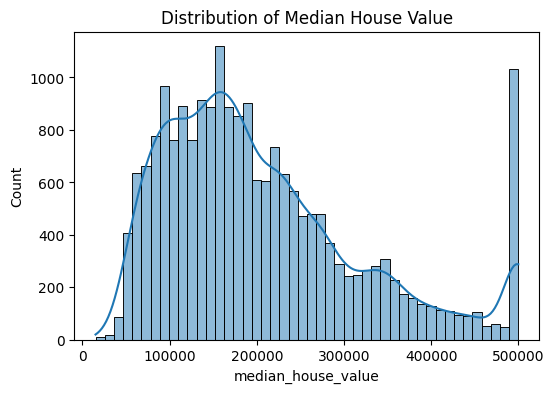

In [11]:
plt.figure(figsize=(6,4))
sns.histplot(df_encoded['median_house_value'], kde=True)
plt.title("Distribution of Median House Value")
plt.show()

* `median_house_value` is right-skewed with a noticeable spike at the $500,000 cap, indicating the value was likely capped during data collection.

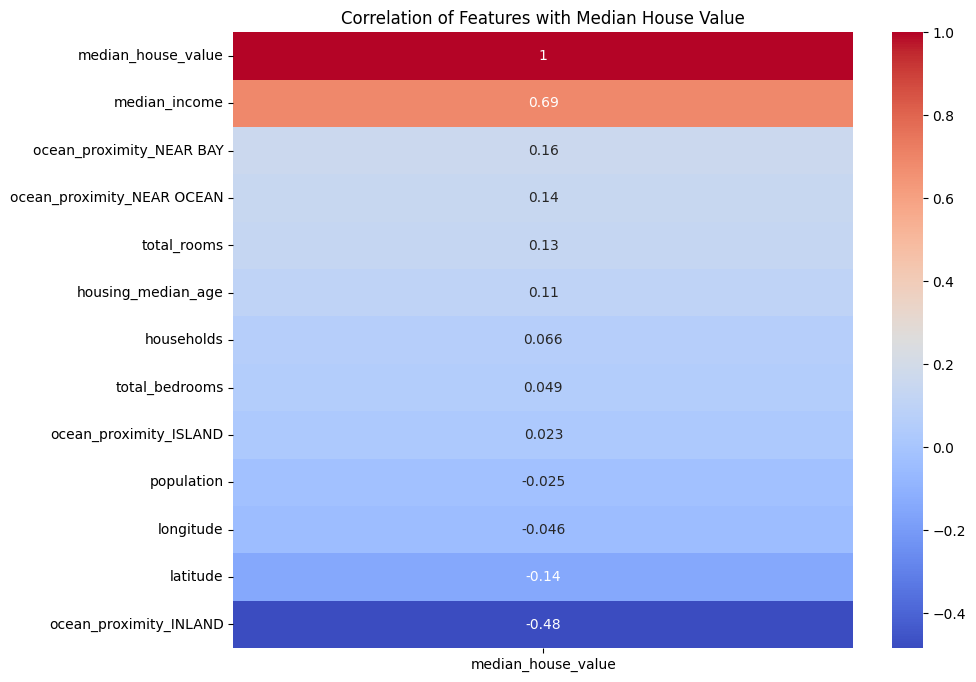

In [12]:
plt.figure(figsize=(10,8))
sns.heatmap(df_encoded.corr(numeric_only=True)[['median_house_value']].sort_values('median_house_value', ascending=False),
            annot=True, cmap='coolwarm')
plt.title("Correlation of Features with Median House Value")
plt.show()

* `median_income` has by far the strongest positive correlation with house value, making it the most important predictor.

## 5. Defining Features (X) and Target (y)

In [13]:
X = df_encoded.drop("median_house_value", axis=1)
y = df_encoded["median_house_value"]
X.shape, y.shape

((20640, 12), (20640,))

## 6. Train / Test Split

In [14]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
X_train.shape, X_test.shape

((16512, 12), (4128, 12))

* The data is split 80/20 into training and test sets, giving 16,512 training rows and 4,128 test rows.

## 7. Feature Scaling

In [15]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

* Scaling is fit only on the training set and applied to the test set, since Ridge and Lasso are sensitive to feature magnitude and this avoids data leakage.

## 8. Linear Regression (Baseline Model)

In [16]:
lr = LinearRegression()
lr.fit(X_train_scaled, y_train)
y_pred_lr = lr.predict(X_test_scaled)

## 9. Ridge Regression

In [17]:
ridge = Ridge(alpha=1.0, random_state=42)
ridge.fit(X_train_scaled, y_train)
y_pred_ridge = ridge.predict(X_test_scaled)

## 10. Lasso Regression

In [18]:
lasso = Lasso(alpha=1000, random_state=42)
lasso.fit(X_train_scaled, y_train)
y_pred_lasso = lasso.predict(X_test_scaled)

## 11. Comparing Coefficients

In [19]:
coef_df = pd.DataFrame({
    'Feature': X.columns,
    'Linear': lr.coef_,
    'Ridge': ridge.coef_,
    'Lasso': lasso.coef_
})
coef_df

,Feature,Linear,Ridge,Lasso
0,longitude,-53826.648016,-53713.651593,-25379.783577
1,latitude,-54415.696144,-54298.400415,-24836.755070
2,housing_median_age,13889.866189,13890.472329,13403.112100
3,total_rooms,-13094.251162,-13058.643741,-0.000000
4,total_bedrooms,43068.181842,42978.328403,27712.608271
5,population,-43403.432427,-43389.968779,-34637.546343
6,households,18382.196324,18425.412550,12536.562389
7,median_income,75167.774766,75157.635752,72041.238325
8,ocean_proximity_INLAND,-18506.095225,-18538.725530,-27057.600197
9,ocean_proximity_ISLAND,2118.437572,2119.249166,1318.217061


* Lasso shrinks the weakest features (`total_rooms` and one ocean-proximity category) to exactly zero, effectively performing feature selection, while Ridge only shrinks all coefficients slightly without eliminating any.

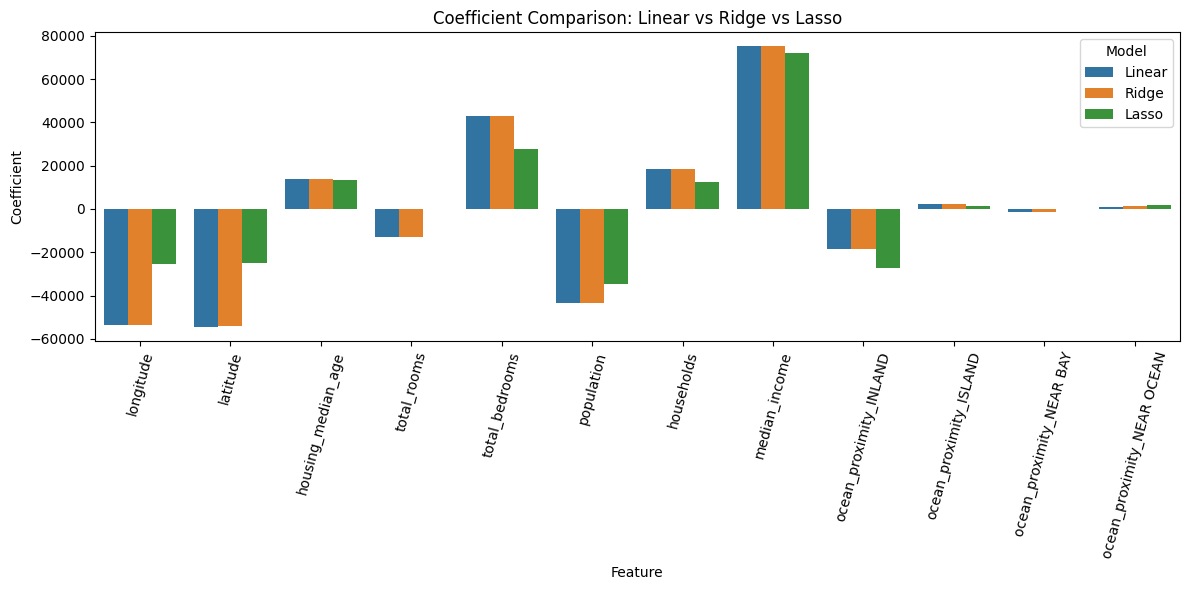

In [20]:
coef_plot_df = coef_df.melt(id_vars='Feature', var_name='Model', value_name='Coefficient')
plt.figure(figsize=(12,6))
sns.barplot(data=coef_plot_df, x='Feature', y='Coefficient', hue='Model')
plt.xticks(rotation=75)
plt.title("Coefficient Comparison: Linear vs Ridge vs Lasso")
plt.tight_layout()
plt.show()

* `median_income` remains the dominant positive coefficient across all three models, confirming it is the most influential and stable predictor.

## 12. Model Evaluation: MAE, MSE, RMSE, R²

In [21]:
def evaluate(y_true, y_pred, model_name):
    mae = mean_absolute_error(y_true, y_pred)
    mse = mean_squared_error(y_true, y_pred)
    rmse = np.sqrt(mse)
    r2 = r2_score(y_true, y_pred)
    return {"Model": model_name, "MAE": mae, "MSE": mse, "RMSE": rmse, "R2": r2}

results = [
    evaluate(y_test, y_pred_lr, "Linear Regression"),
    evaluate(y_test, y_pred_ridge, "Ridge Regression"),
    evaluate(y_test, y_pred_lasso, "Lasso Regression"),
]

results_df = pd.DataFrame(results).set_index("Model")
results_df

,MAE,MSE,RMSE,R2
Model,,,,
Linear Regression,50670.738241,4.908477e+09,70060.521845,0.625424
Ridge Regression,50668.122931,4.908042e+09,70057.416870,0.625457
Lasso Regression,50686.012160,4.944800e+09,70319.273923,0.622652


* Linear and Ridge Regression produce nearly identical error metrics, while Lasso is marginally higher, reflecting the small accuracy cost of shrinking two features to zero.

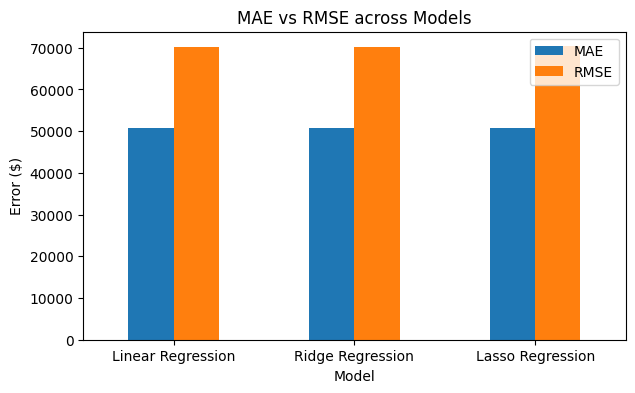

In [22]:
results_df[['MAE','RMSE']].plot(kind='bar', figsize=(7,4))
plt.title("MAE vs RMSE across Models")
plt.ylabel("Error ($)")
plt.xticks(rotation=0)
plt.show()

* RMSE is consistently higher than MAE for every model, which is expected since RMSE penalizes larger errors more heavily.

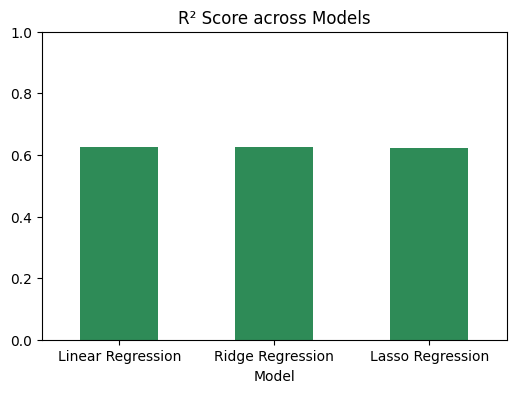

In [23]:
results_df['R2'].plot(kind='bar', figsize=(6,4), color='seagreen')
plt.title("R² Score across Models")
plt.ylim(0, 1)
plt.xticks(rotation=0)
plt.show()

* R² scores are nearly identical across the three models, all explaining roughly 62-63% of the variance in house prices.

## 13. Train vs Test Performance (Checking Generalization)

In [24]:
train_scores = []
for name, model in [("Linear Regression", lr), ("Ridge Regression", ridge), ("Lasso Regression", lasso)]:
    y_train_pred = model.predict(X_train_scaled)
    train_scores.append({
        "Model": name,
        "Train_R2": r2_score(y_train, y_train_pred),
        "Test_R2": r2_score(y_test, model.predict(X_test_scaled))
    })

pd.DataFrame(train_scores).set_index("Model")

,Train_R2,Test_R2
Model,,
Linear Regression,0.649665,0.625424
Ridge Regression,0.649665,0.625457
Lasso Regression,0.643048,0.622652


* Train and test R² scores are close for all three models, showing none of them is meaningfully overfitting; Lasso has the smallest train R², consistent with it discarding two features.

## 14. Conclusion

* **Best model:** Ridge Regression generalizes best. Its test R² (0.6255) and RMSE ($70,057) are marginally better than plain Linear Regression (R² 0.6254, RMSE $70,061), and its train/test gap is virtually identical to Linear Regression's, so it keeps coefficients smaller and more stable at essentially zero accuracy cost.
* **Effect of regularization:** Ridge shrinks all coefficients slightly but keeps every feature, giving it near-identical accuracy to plain Linear Regression. Lasso, at a higher penalty, zeroes out the two weakest features (`total_rooms` and the `NEAR BAY` dummy) and performs implicit feature selection, but this drops test R² slightly to 0.6227 and raises RMSE to about $70,319.
* **Overall:** Because train and test scores are close for all three models, the dataset shows very little overfitting to begin with, so regularization's main benefit here is coefficient stability (Ridge) and simplification via feature elimination (Lasso) rather than a large accuracy gain.